# Lakeside desktop sim playground

Same story as the **Rust desktop app**, in notebook cells:

1. **Actual peaking day** from the real 15-min store (typically 2026-01-26)  
2. Measured OAT / midnight state from that day  
3. Strategy → control schedule  
4. ONNX hybrid walk = **baseline + E+ delta** on that same day  
5. Peak / kWh / incremental demand (vs actual day peak)  
6. Overlay: **actual** · **24/7 (at-temp)** · **do-nothing** · **random strategy**  
7. **Cold-snap** — daytype audit + **EnergyPlus-only** (no ML) for all 3 strategies  

Needs `real_baseline_15min_v1.onnx` + `eplus_delta_15min_v1.onnx` under `ml/artifacts`
(or `desktop/artifacts` via promote), plus site `ml/artifacts/real_baseline_15min_v1.parquet`.
No training in this notebook.


In [1]:
%matplotlib inline
from datetime import datetime
print("KERNEL ALIVE", datetime.now().isoformat(timespec="seconds"), flush=True)

import json, os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path("..").resolve()
if not (ROOT / "ml").is_dir():
    ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "ml"))
sys.path.insert(0, str(ROOT / "scripts"))

from artifact_paths import artifact_paths
from notebook_plots import apply_notebook_theme, save_fig
from hybrid_rollout import (
    STEPS,
    HybridModels,
    load_hybrid_onnx,
    schedule_from_strategy_fixture,
    rollout_96,
)
from feature_compile_heating_dsm import STRATEGY_IDS, ZONE_TEMP_COLS
from simulation_contract import incremental_demand
apply_notebook_theme()
PATHS = artifact_paths()
OUT = PATHS["figures"].parent
FIG = PATHS["figures"]
FIG.mkdir(parents=True, exist_ok=True)
DESK = ROOT / "desktop" / "artifacts"

# Hardcoded site SoT (survives reboot — no env vars required).
SITE = Path(r"C:\Users\ben\OneDrive\Desktop\testing\sp_creekside")
if not SITE.is_dir() or not (SITE / "reports").is_dir():
    raise FileNotFoundError(f"site missing or incomplete: {SITE}")
os.environ["LAKESIDE_SITE_ROOT"] = str(SITE)  # for any lakeside.* imports later

def _find(name: str) -> Path:
    for d in (OUT, DESK):
        p = Path(d) / name
        if p.is_file():
            return p
    raise FileNotFoundError(
        f"missing {name} under {OUT} or {DESK} — run ship_best_to_desktop.py first"
    )

base_onnx = _find("real_baseline_15min_v1.onnx")
delta_onnx = _find("eplus_delta_15min_v1.onnx")
models = load_hybrid_onnx(base_onnx, delta_onnx)
print("ONNX baseline", base_onnx)
print("ONNX delta", delta_onnx)
print("features", len(models.feature_cols))
print("SITE", SITE)
print("SETUP COMPLETE", flush=True)


KERNEL ALIVE 2026-08-10T12:58:06
ONNX baseline C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\real_baseline_15min_v1.onnx
ONNX delta C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\eplus_delta_15min_v1.onnx
features 46
SITE C:\Users\ben\OneDrive\Desktop\testing\sp_creekside
SETUP COMPLETE


## 1 · Peak day from actual BAS (not a fake cold day)

Load the highest-demand **complete** day from the real 15-min store (typically
**2026-01-26**). Midnight state + OAT + actual `facility_kw` come from that day
so later overlays are apples-to-apples with the meter.


In [2]:
REAL_PARQUET = SITE / "ml" / "artifacts" / "real_baseline_15min_v1.parquet"
demand_rate_per_kw = 12.0
energy_rate_per_kwh = 0.08
PEAK_DAY_PREF = "2026-01-26"

def _load_peak_day(path: Path, prefer: str | None = None) -> tuple[pd.DataFrame, object]:
    df = pd.read_parquet(path)
    df = df.copy()
    df["timestamp_local"] = pd.to_datetime(df["timestamp_local"])
    daily = (
        df.groupby(df["timestamp_local"].dt.date)["facility_kw"]
        .agg(peak="max", n="count")
        .query("n >= 90")
        .sort_values("peak", ascending=False)
    )
    if daily.empty:
        raise RuntimeError(f"no complete days in {path}")
    if prefer:
        pref = pd.Timestamp(prefer).date()
        if pref in daily.index:
            day = pref
        else:
            day = daily.index[0]
            print(f"prefer {prefer} missing — using {day}")
    else:
        day = daily.index[0]
    sub = df[df["timestamp_local"].dt.date == day].sort_values("timestamp_local")
    # one row per 15-min step if duplicates
    if "step_15" in sub.columns:
        sub = sub.drop_duplicates("step_15", keep="first")
    sub = sub.head(STEPS).reset_index(drop=True)
    if len(sub) < STEPS:
        raise RuntimeError(f"peak day {day} has only {len(sub)} rows")
    return sub, day

peak_day_df, peak_day = _load_peak_day(REAL_PARQUET, PEAK_DAY_PREF)
kw_actual = peak_day_df["facility_kw"].to_numpy(dtype=float)
oat_96 = peak_day_df["oat_f"].to_numpy(dtype=float)
rh_96 = peak_day_df["rh_pct"].to_numpy(dtype=float) if "rh_pct" in peak_day_df else np.full(STEPS, 55.0)
ghi_96 = peak_day_df["ghi"].to_numpy(dtype=float) if "ghi" in peak_day_df else np.zeros(STEPS)
midnight_facility_kw = float(kw_actual[0])
midnight_zones_f = [float(peak_day_df.iloc[0][c]) for c in ZONE_TEMP_COLS]
oat_midnight_f = float(oat_96[0])
# Demand counterfactual: peak established BEFORE this day (not this day's actual peak).
try:
    _all = pd.read_parquet(REAL_PARQUET)
    _all["timestamp_local"] = pd.to_datetime(_all["timestamp_local"])
    _all["day"] = _all["timestamp_local"].dt.strftime("%Y-%m-%d")
    _daily_peaks = _all.groupby("day")["facility_kw"].max().to_dict()
    from billing_counterfactual import mtd_peak_before_day as _mtd
    existing_billing_peak_kw = float(_mtd(_daily_peaks, str(peak_day)))
except Exception as _e:
    print("MTD billing peak fallback:", _e)
    existing_billing_peak_kw = 0.0
print(
    "existing_billing_peak_kw (MTD before target day; ILLUSTRATIVE tariff later)=",
    existing_billing_peak_kw,
)
# Month peak-to-date replay summary (ILLUSTRATIVE $/kW · $/kWh)
try:
    from billing_month_replay import replay_month
    _month = str(peak_day)[:7]
    _kwh = (
        _all.groupby("day")["facility_kw"].sum().mul(0.25).to_dict()
        if "_all" in dir()
        else {str(peak_day): float(kw_actual.sum() * 0.25)}
    )
    _peaks = _daily_peaks if "_daily_peaks" in dir() else {str(peak_day): float(kw_actual.max())}
    _rep = replay_month(_kwh, _peaks, month=_month)
    print(
        "month_replay",
        _rep.month,
        "peak_kw",
        round(_rep.month_peak_kw, 1),
        "total_incremental_$",
        round(_rep.total_cost, 1),
        _rep.tariff_note,
    )
except Exception as _e:
    print("month_replay skipped:", _e)
cal_month = float(peak_day_df.iloc[0].get("month", pd.Timestamp(peak_day).month))
cal_doy = float(peak_day_df.iloc[0].get("doy", pd.Timestamp(peak_day).dayofyear))
cal_weekend = float(peak_day_df.iloc[0].get("is_weekend", int(pd.Timestamp(peak_day).dayofweek >= 5)))
if "occupied" in peak_day_df.columns:
    occ_96 = [float(x) for x in peak_day_df["occupied"].to_numpy(dtype=float)]
else:
    occ_96 = [1.0 if 7 <= (s // 4) < 18 else 0.0 for s in range(STEPS)]

print("peak day", peak_day, "n", len(peak_day_df))
print("actual peak", float(kw_actual.max()), "kW @ step", int(np.argmax(kw_actual)))
print("midnight kW", midnight_facility_kw, "OAT", oat_midnight_f)
print("zones", [round(z, 1) for z in midnight_zones_f])


existing_billing_peak_kw (MTD before target day; ILLUSTRATIVE tariff later)= 273.99999333333335
month_replay 2026-01 peak_kw 298.0 total_incremental_$ 10308.6 ILLUSTRATIVE energy=$0.08/kWh demand=$12/kW — not verified Lakeside utility tariff
peak day 2026-01-26 n 96
actual peak 298.0 kW @ step 14
midnight kW 98.0 OAT -0.9416666666666668
zones [61.5, 61.3, 62.2, 61.2, 62.0, 60.8]


## 2 · Weather on that peak day (measured OAT)


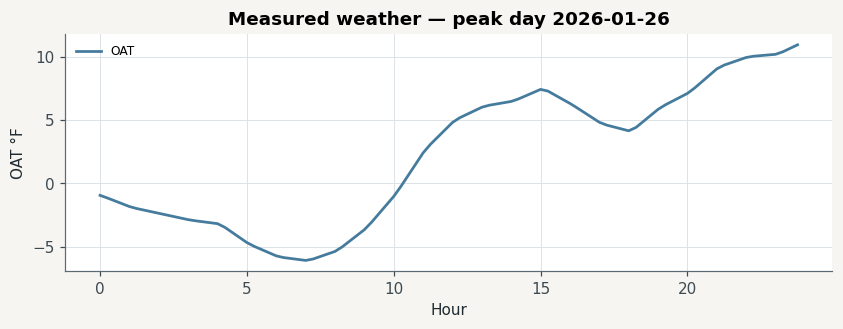

OAT min/max -6.074999999999999 10.933333333333335


In [3]:
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(np.arange(STEPS) / 4.0, oat_96, color="#457b9d", lw=1.8, label="OAT")
ax.set_xlabel("Hour"); ax.set_ylabel("OAT °F")
ax.set_title(f"Measured weather — peak day {peak_day}")
ax.legend(frameon=False, fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
save_fig(FIG / "playground_oat.png", fig); plt.close(fig)
print("OAT min/max", float(np.min(oat_96)), float(np.max(oat_96)))


## 3 · Strategy → ControlSchedule96


In [4]:
strategy_id = "stagger_preheat" if "stagger_preheat" in STRATEGY_IDS else STRATEGY_IDS[0]
baseline_id = "baseline" if "baseline" in STRATEGY_IDS else STRATEGY_IDS[0]
flat_id = "flat_24_7" if "flat_24_7" in STRATEGY_IDS else baseline_id
nothing_id = "deep_setback" if "deep_setback" in STRATEGY_IDS else baseline_id

# One random named strategy each Run All (excludes 24/7 + deep setback).
_pool = [
s for s in STRATEGY_IDS
if s not in (flat_id, nothing_id) and not str(s).startswith("prbs")
]
_rng_pick = np.random.default_rng()
random_id = str(_rng_pick.choice(_pool)) if _pool else strategy_id

base_sched = schedule_from_strategy_fixture(baseline_id)
flat_sched = schedule_from_strategy_fixture(flat_id)
nothing_sched = schedule_from_strategy_fixture(nothing_id)
random_sched = schedule_from_strategy_fixture(random_id)
print("24/7 HVAC", flat_id, "| do-nothing", nothing_id, "| random pick", random_id)
print("BAU schedule", baseline_id, "| (enum still uses all)", list(STRATEGY_IDS))


24/7 HVAC flat_24_7 | do-nothing deep_setback | random pick morning_all_on
BAU schedule baseline | (enum still uses all) ['baseline', 'stagger_preheat', 'flat_24_7', 'deep_setback', 'morning_all_on']


## 4 · ONNX hybrid walks on the **same** peak day

Weather is the peaking day's measured OAT/RH/GHI for every arm.  
`hybrid = real_baseline_ONNX + eplus_delta_ONNX`.

**Two distinct 24/7 experiments (do not conflate):**

1. **SAME_STATE_TREATMENT_TEST** — every strategy (incl. 24/7) starts from the
   **same measured 00:00** state. Tests action response from now forward.
2. **FULL_OVERNIGHT_COUNTERFACTUAL** — controls begin on D−1; each strategy creates
   its own midnight; pre-midnight energy belongs in the economics. Future optimizer
   default.

This notebook's gray **`flat_24_7` at-temp init** is a *partial* overnight story
(warm midnight assumed) — **not** a fair daily energy comparison against setback
BAU, and **not** Experiment 1. Labels stay ILLUSTRATIVE / HYBRID_SCREENING.

**Read this chart carefully:** IdealLoads delta is still **HYBRID_SCREENING /
smoke**. A DSM strategy can raise peak vs actual — that is a model/farm limit,
not proof that preheat is worse in the real plant.


In [5]:
COMFORT_HTG_SP_F = 68.0

def _at_temp_overnight_kw(oat_f: float) -> float:
    """Steady overnight kW while zones already near occupied SP (similar OAT)."""
    full = pd.read_parquet(REAL_PARQUET)
    full = full.copy()
    full["timestamp_local"] = pd.to_datetime(full["timestamp_local"])
    zmean = full[list(ZONE_TEMP_COLS)].mean(axis=1)
    hour = full["timestamp_local"].dt.hour
    mask = (hour <= 5) & (zmean >= COMFORT_HTG_SP_F - 1.0) & (zmean <= COMFORT_HTG_SP_F + 2.5)
    if "oat_f" in full.columns:
        mask = mask & ((full["oat_f"] - float(oat_f)).abs() <= 5.0)
    if mask.any():
        return float(full.loc[mask, "facility_kw"].median())
    return float(midnight_facility_kw)

def _init_state(*, already_at_temp: bool) -> dict:
    oat0 = float(oat_96[0])
    if already_at_temp:
        # 24/7 counterfactual: held at occupied SP overnight (not actual setback).
        return {
            "facility_kw": float(_at_temp_overnight_kw(oat0)),
            "oat_f": oat0,
            **{ZONE_TEMP_COLS[i]: float(COMFORT_HTG_SP_F) for i in range(6)},
        }
    return {
        "facility_kw": float(midnight_facility_kw),
        "oat_f": oat0,
        **{ZONE_TEMP_COLS[i]: float(midnight_zones_f[i]) for i in range(6)},
    }

def make_contract(dsm_control: dict, *, strategy_label: str) -> dict:
    already = strategy_label == flat_id
    return {
        "contract_version": "hybrid_dsm_96_v1",
        "init": _init_state(already_at_temp=already),
        "weather_forecast_96": {
            "oat_f": [float(x) for x in oat_96],
            "rh_pct": [float(x) for x in rh_96],
            "ghi": [float(x) for x in ghi_96],
        },
        "baseline_control_96": base_sched,
        "dsm_control_96": dsm_control,
        "calendar": {
            "month": float(cal_month),
            "doy": float(cal_doy),
            "is_weekend": float(cal_weekend),
            "occupied_schedule": list(occ_96),
        },
        "comfort_htg_sp_f": float(COMFORT_HTG_SP_F),
        "comfort_band_f": 2.0,
        "strategy_id": strategy_label,
    }

walk_bau = rollout_96(models, make_contract(base_sched, strategy_label=baseline_id))
walk_247 = rollout_96(models, make_contract(flat_sched, strategy_label=flat_id))
walk_nothing = rollout_96(models, make_contract(nothing_sched, strategy_label=nothing_id))
walk_random = rollout_96(models, make_contract(random_sched, strategy_label=random_id))

def series(walk, key="hybrid_facility_kw"):
    return np.array([float(s[key]) for s in walk["steps"][:STEPS]], dtype=float)

kw_bau = series(walk_bau)
kw_247 = series(walk_247)
kw_nothing = series(walk_nothing)
kw_random = series(walk_random)
kw_ml_base_arm = series(walk_bau, "baseline_facility_kw")

print(f"actual peak {float(kw_actual.max()):.1f} kW")
print(f"24/7 ({flat_id}) peak {float(kw_247.max()):.1f} kW  (init @ {COMFORT_HTG_SP_F:g}°F)")
print(f"do-nothing ({nothing_id}) peak {float(kw_nothing.max()):.1f} kW")
print(f"random ({random_id}) peak {float(kw_random.max()):.1f} kW")
print("24/7 init facility_kw", round(float(_init_state(already_at_temp=True)["facility_kw"]), 1),
      "| metered midnight", round(float(midnight_facility_kw), 1))
print("comfort violations — nothing", walk_nothing["summary"].get("comfort_violations"),
      "| random", walk_random["summary"].get("comfort_violations"))


actual peak 298.0 kW
24/7 (flat_24_7) peak 887.3 kW  (init @ 68°F)
do-nothing (deep_setback) peak 590.8 kW
random (morning_all_on) peak 693.2 kW
24/7 init facility_kw 192.0 | metered midnight 98.0
comfort violations — nothing 142 | random 114


## 5 · Costs — energy + **incremental** demand (not full monthly)


In [6]:
def day_stats(kw: np.ndarray) -> dict:
    peak = float(kw.max())
    kwh = float(kw.sum() * 0.25)
    energy_cost = kwh * energy_rate_per_kwh
    # billing peak to-date = this day's actual peak (counterfactual day in isolation)
    new_p, inc_kw, inc_cost = incremental_demand(
    float(kw_actual.max()), peak, demand_rate_per_kw
    )
    return {
    "peak_kw": peak,
    "kwh": kwh,
    "energy_$": energy_cost,
    "new_billing_peak": new_p,
    "inc_demand_kw": inc_kw,
    "inc_demand_$": inc_cost,
    "total_inc_$": energy_cost + inc_cost,
    }

stats = pd.DataFrame({
"Actual meter": day_stats(kw_actual),
f"24/7 ({flat_id})": day_stats(kw_247),
f"Do-nothing ({nothing_id})": day_stats(kw_nothing),
f"Random ({random_id})": day_stats(kw_random),
}).T
display(stats.round(2))
display(Markdown(
"Incremental demand here asks: does this **counterfactual** raise peak "
f"**above the actual peaking day** ({float(kw_actual.max()):.0f} kW)? "
"Smoke IdealLoads deltas often fail that test — read as screening, not savings."
))


,peak_kw,kwh,energy_$,new_billing_peak,inc_demand_kw,inc_demand_$,total_inc_$
Actual meter,298.00,4195.00,335.60,298.00,0.00,0.00,335.60
24/7 (flat_24_7),887.28,7805.63,624.45,887.28,589.28,7071.40,7695.85
Do-nothing (deep_setback),590.76,4205.03,336.40,590.76,292.76,3513.15,3849.56
Random (morning_all_on),693.22,4196.46,335.72,693.22,395.22,4742.65,5078.36


Incremental demand here asks: does this **counterfactual** raise peak **above the actual peaking day** (298 kW)? Smoke IdealLoads deltas often fail that test — read as screening, not savings.

## 6 · Overlay — same peak day, same weather

Black = **actual meter**. Gray = **24/7** (already at occupied temp). Teal = **do-nothing**
(`deep_setback`). Orange = **random** named strategy from this Run All.

IdealLoads delta is still screening/smoke — wild peaks are model limits, not plant truth.


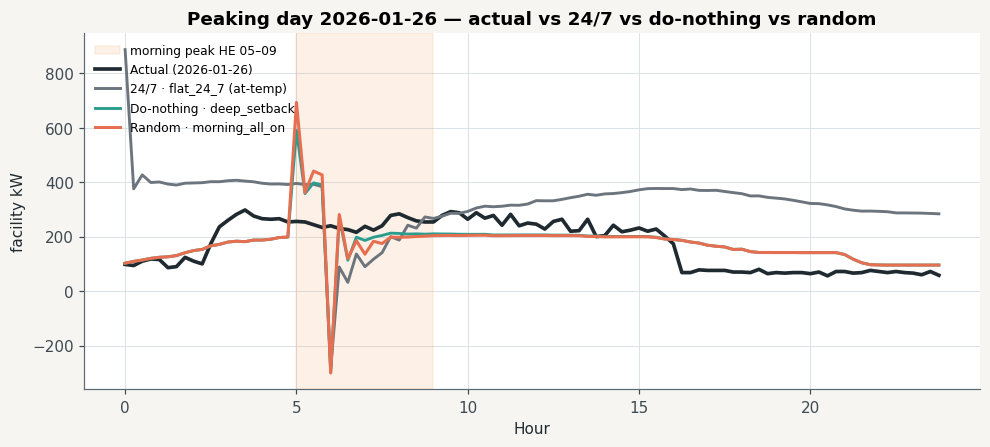

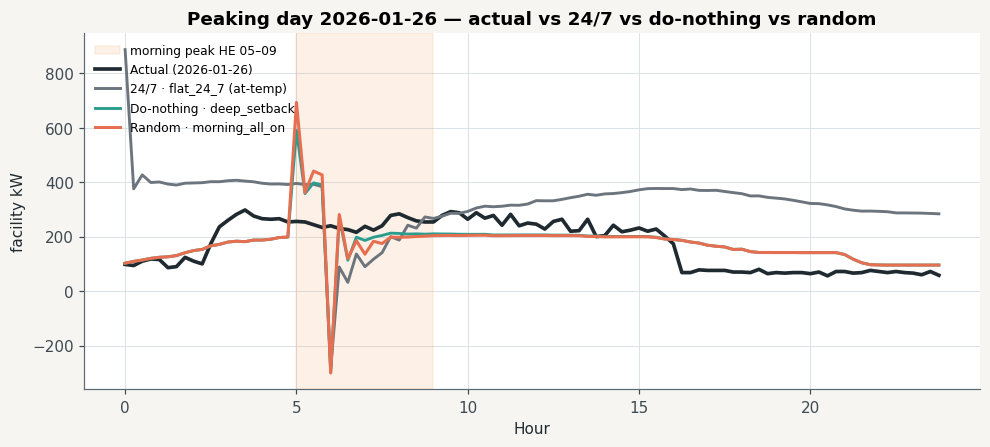

peaks — actual / 24/7 / nothing / random: 298.0 887.3 590.8 693.2
random strategy this run: morning_all_on


In [7]:
t = np.arange(STEPS) / 4.0
fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.axvspan(5, 9, color="#f4a261", alpha=0.15, label="morning peak HE 05–09")
ax.plot(t, kw_actual, color="#1f2a30", lw=2.4, label=f"Actual ({peak_day})")
ax.plot(t, kw_247, color="#6c757d", lw=1.9, label=f"24/7 · {flat_id} (at-temp)")
ax.plot(t, kw_nothing, color="#2a9d8f", lw=1.9, label=f"Do-nothing · {nothing_id}")
ax.plot(t, kw_random, color="#e76f51", lw=2.0, label=f"Random · {random_id}")
ax.set_xlabel("Hour"); ax.set_ylabel("facility kW")
ax.set_title(f"Peaking day {peak_day} — actual vs 24/7 vs do-nothing vs random")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
save_fig(FIG / "playground_peakday_overlay.png", fig)
plt.show()
plt.close(fig)

print("peaks — actual / 24/7 / nothing / random:",
      round(float(kw_actual.max()), 1),
      round(float(kw_247.max()), 1),
      round(float(kw_nothing.max()), 1),
      round(float(kw_random.max()), 1))
print("random strategy this run:", random_id)


## 7 · Cold-snap · daytype audit · **EnergyPlus-only** (no ML)

The hybrid ONNX walk can go negative / spike — treat it as screening noise.
This section loads the **IdealLoads+COP DSM farm** (`eplus/dsm_farm_paired`) for the
same three strategies and overlays **actual meter** on the **same calendar days**.

**Daytype matters:** Sat/Sun vs Mon schedules dominate load shape. We pick snap days
that (1) exist in the E+ farm and (2) print weekday/weekend + meter peak so you can
see the mix. (Farm historically used every-other cold day — peak Mon 2026-01-26 may
not have an IdealLoads DSM run.)


### Daytype / farm coverage (validate before trusting shapes)

,day,weekday,is_weekend_calendar,is_weekend_feature,meter_peak_kw,mean_oat_f,occ_frac_mean,in_eplus_farm,note
0,2026-01-23,Friday,False,False,252.0,-11.5,0.4,True,
1,2026-01-25,Sunday,True,True,148.0,0.0,0.0,True,
2,2026-01-27,Tuesday,False,False,278.0,9.3,0.4,True,


peak meter day 2026-01-26 | E+ snap days ['2026-01-23', '2026-01-25', '2026-01-27']
strategies ['flat_24_7', 'deep_setback', 'morning_all_on']


Weekend flags in snap: **[False, True, False]** · weekday names: **['Friday', 'Sunday', 'Tuesday']**. If this is all weekend while the peaking day is a Monday, shapes will not match school occupancy.

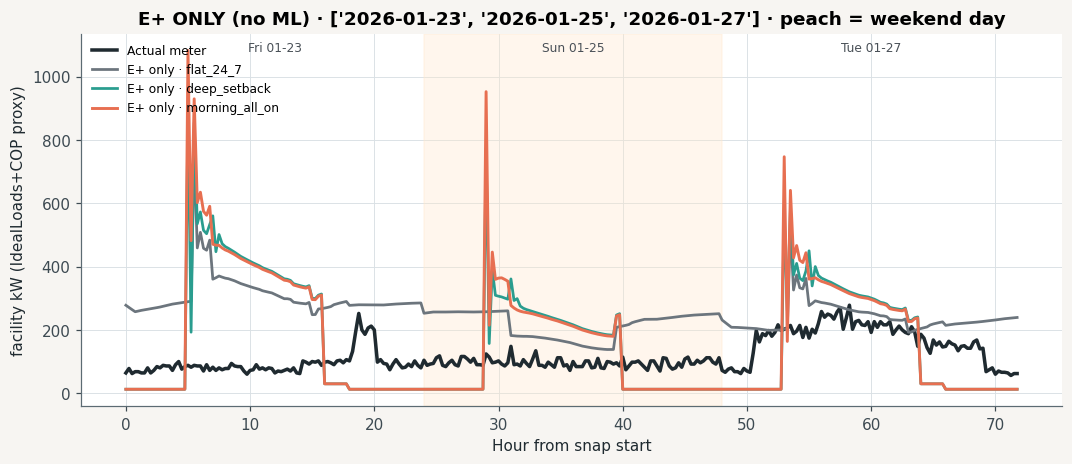

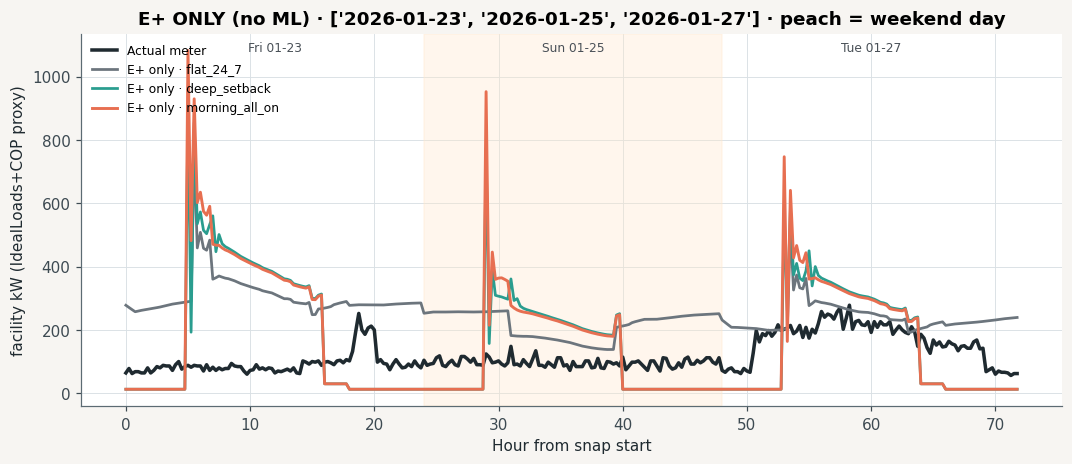

### E+ only — per-day peaks (IdealLoads+COP screening, not W2A plant twin)

,day,weekday,weekend,peak_actual,peak_eplus_flat_24_7,peak_eplus_deep_setback,peak_eplus_morning_all_on
0,2026-01-23,Friday,False,252.0,758.7,902.1,1083.0
1,2026-01-25,Sunday,True,148.0,260.3,773.9,952.7
2,2026-01-27,Tuesday,False,278.0,522.0,584.4,747.1


_Honesty:_ these are **IdealLoads + fixed COP** DSM farm proxies (`HYBRID_SCREENING`), not the W2A A04 plant twin. Absolute kW will not match the meter; use for **strategy shape / ranking**, then compare daytypes above.

E+ peaks — actual / 24/7 / nothing / random: 278.0 758.7 902.1 1083.0


In [8]:
N_SNAP = 3
SPINUP_DAYS = 1
FARM = SITE / "eplus" / "dsm_farm_paired"
EPLUS_STRATS = [flat_id, nothing_id, random_id]

def _day_frame(day) -> pd.DataFrame:
    day = pd.Timestamp(day).date()
    full = pd.read_parquet(REAL_PARQUET)
    full = full.copy()
    full["timestamp_local"] = pd.to_datetime(full["timestamp_local"])
    sub = full[full["timestamp_local"].dt.date == day].sort_values("timestamp_local")
    if "step_15" in sub.columns:
        sub = sub.drop_duplicates("step_15", keep="first")
    sub = sub.head(STEPS).reset_index(drop=True)
    if len(sub) < STEPS:
        raise RuntimeError(f"{day} has only {len(sub)} rows in meter store")
    return sub

def _farm_days_for(strats: list[str]) -> list[str]:
    from collections import defaultdict
    by = defaultdict(set)
    if not FARM.is_dir():
        return []
    for p in FARM.iterdir():
        if not p.is_dir() or not (p / "timestep_proxy_mat.parquet").is_file():
            continue
        name = p.name  # YYYY-MM-DD_strategy_hash
        day = name[:10]
        strat = name[11:].rsplit("_", 1)[0]
        by[day].add(strat)
    need = set(strats)
    return sorted(d for d, s in by.items() if need <= s)

def _pick_snap_days(peak, n: int, farm_days: list[str]) -> list[str]:
    """n farm days closest to peak (keeps E+ + meter aligned)."""
    if not farm_days:
        raise FileNotFoundError(f"no E+ farm days under {FARM} for {EPLUS_STRATS}")
    peak_ts = pd.Timestamp(peak)
    ranked = sorted(farm_days, key=lambda d: abs((pd.Timestamp(d) - peak_ts).days))
    # keep chronological order of the n nearest
    chosen = sorted(ranked[:n], key=lambda d: pd.Timestamp(d))
    return chosen

def _daytype_table(days: list[str]) -> pd.DataFrame:
    rows = []
    farm_set = set(_farm_days_for(EPLUS_STRATS))
    for d in days:
        ts = pd.Timestamp(d)
        try:
            df = _day_frame(d)
            peak_a = float(df["facility_kw"].max())
            mean_oat = float(df["oat_f"].mean()) if "oat_f" in df else np.nan
            occ = float(df["occupied"].mean()) if "occupied" in df.columns else np.nan
            is_we_feat = float(df.iloc[0]["is_weekend"]) if "is_weekend" in df.columns else float(ts.dayofweek >= 5)
        except Exception as e:
            peak_a = mean_oat = occ = is_we_feat = np.nan
            err = str(e)[:60]
        else:
            err = ""
        rows.append({
            "day": str(pd.Timestamp(d).date()),
            "weekday": ts.day_name(),
            "is_weekend_calendar": bool(ts.dayofweek >= 5),
            "is_weekend_feature": bool(is_we_feat) if pd.notna(is_we_feat) else None,
            "meter_peak_kw": peak_a,
            "mean_oat_f": mean_oat,
            "occ_frac_mean": occ,
            "in_eplus_farm": str(pd.Timestamp(d).date()) in farm_set or d in farm_set,
            "note": err,
        })
    return pd.DataFrame(rows)

def load_eplus_kw(day: str, strategy: str) -> np.ndarray:
    day = str(pd.Timestamp(day).date())
    runs = sorted(FARM.glob(f"{day}_{strategy}_*"))
    runs = [r for r in runs if (r / "timestep_proxy_mat.parquet").is_file()]
    if not runs:
        raise FileNotFoundError(f"missing E+ run {day} / {strategy} under {FARM}")
    ts = pd.read_parquet(runs[-1] / "timestep_proxy_mat.parquet")  # latest hash
    col = "site_electric_proxy_kw" if "site_electric_proxy_kw" in ts.columns else "facility_kw"
    kw = ts[col].to_numpy(dtype=float)
    if len(kw) < STEPS:
        raise RuntimeError(f"{runs[-1].name} has {len(kw)} steps")
    return kw[:STEPS]

farm_days = _farm_days_for(EPLUS_STRATS)
snap_days = _pick_snap_days(peak_day, N_SNAP, farm_days)
daytypes = _daytype_table(snap_days)

display(Markdown("### Daytype / farm coverage (validate before trusting shapes)"))
display(daytypes.round(1))
print("peak meter day", peak_day, "| E+ snap days", snap_days)
print("strategies", EPLUS_STRATS)
if not daytypes["in_eplus_farm"].all():
    display(Markdown("**WARNING:** some snap days missing from E+ farm — chart will fail."))
we_mix = daytypes["is_weekend_calendar"].tolist()
display(Markdown(
    f"Weekend flags in snap: **{we_mix}** · "
    f"weekday names: **{daytypes['weekday'].tolist()}**. "
    "If this is all weekend while the peaking day is a Monday, shapes will not match school occupancy."
))

# --- EnergyPlus-only stacked series (no ML) ---
ep_actual, ep_247, ep_nothing, ep_random = [], [], [], []
ep_per_day = []
for d in snap_days:
    df = _day_frame(d)
    a = df["facility_kw"].to_numpy(dtype=float)[:STEPS]
    k247 = load_eplus_kw(d, flat_id)
    kn = load_eplus_kw(d, nothing_id)
    kr = load_eplus_kw(d, random_id)
    ep_actual.append(a); ep_247.append(k247); ep_nothing.append(kn); ep_random.append(kr)
    ep_per_day.append({
        "day": str(pd.Timestamp(d).date()),
        "weekday": pd.Timestamp(d).day_name(),
        "weekend": bool(pd.Timestamp(d).dayofweek >= 5),
        "peak_actual": float(a.max()),
        f"peak_eplus_{flat_id}": float(k247.max()),
        f"peak_eplus_{nothing_id}": float(kn.max()),
        f"peak_eplus_{random_id}": float(kr.max()),
    })

ep_actual = np.concatenate(ep_actual)
ep_247 = np.concatenate(ep_247)
ep_nothing = np.concatenate(ep_nothing)
ep_random = np.concatenate(ep_random)
t_h = np.arange(len(ep_actual)) / 4.0

fig, ax = plt.subplots(figsize=(11.5, 4.4))
# shade each calendar day + label weekday
for i, d in enumerate(snap_days):
    x0, x1 = i * 24.0, (i + 1) * 24.0
    if pd.Timestamp(d).dayofweek >= 5:
        ax.axvspan(x0, x1, color="#ffe8cc", alpha=0.35)
    ax.text(
        (x0 + x1) / 2, 0.98,
        f"{pd.Timestamp(d).strftime('%a %m-%d')}",
        transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=8, color="#495057",
    )
ax.plot(t_h, ep_actual, color="#1f2a30", lw=2.3, label="Actual meter")
ax.plot(t_h, ep_247, color="#6c757d", lw=1.8, label=f"E+ only · {flat_id}")
ax.plot(t_h, ep_nothing, color="#2a9d8f", lw=1.8, label=f"E+ only · {nothing_id}")
ax.plot(t_h, ep_random, color="#e76f51", lw=1.9, label=f"E+ only · {random_id}")
ax.set_xlabel("Hour from snap start"); ax.set_ylabel("facility kW (IdealLoads+COP proxy)")
ax.set_title(
    f"E+ ONLY (no ML) · {snap_days} · peach = weekend day"
)
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
save_fig(FIG / "playground_coldsnap_eplus_only.png", fig)
plt.show(); plt.close(fig)

ep_day_df = pd.DataFrame(ep_per_day)
display(Markdown("### E+ only — per-day peaks (IdealLoads+COP screening, not W2A plant twin)"))
display(ep_day_df.round(1))
display(Markdown(
    "_Honesty:_ these are **IdealLoads + fixed COP** DSM farm proxies (`HYBRID_SCREENING`), "
    "not the W2A A04 plant twin. Absolute kW will not match the meter; use for "
    "**strategy shape / ranking**, then compare daytypes above."
))
print("E+ peaks — actual / 24/7 / nothing / random:",
      round(float(ep_actual.max()), 1),
      round(float(ep_247.max()), 1),
      round(float(ep_nothing.max()), 1),
      round(float(ep_random.max()), 1))


## 7b · Same days · ML hybrid (for contrast — expect garbage spikes)

Same farm-aligned snap days as §7, but ONNX hybrid. Spin-up shaded. Use this only to
see how far the ML sits from E+/meter — not for decisions.


**ML cold-snap walks rejected** (plant cap 450 kW / scorecard). Do not use these series for strategy decisions — see §7 E+-only.

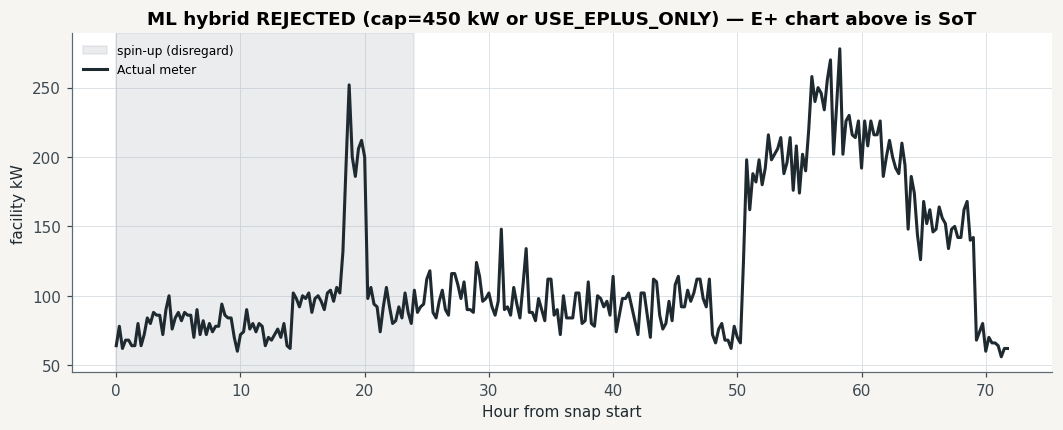

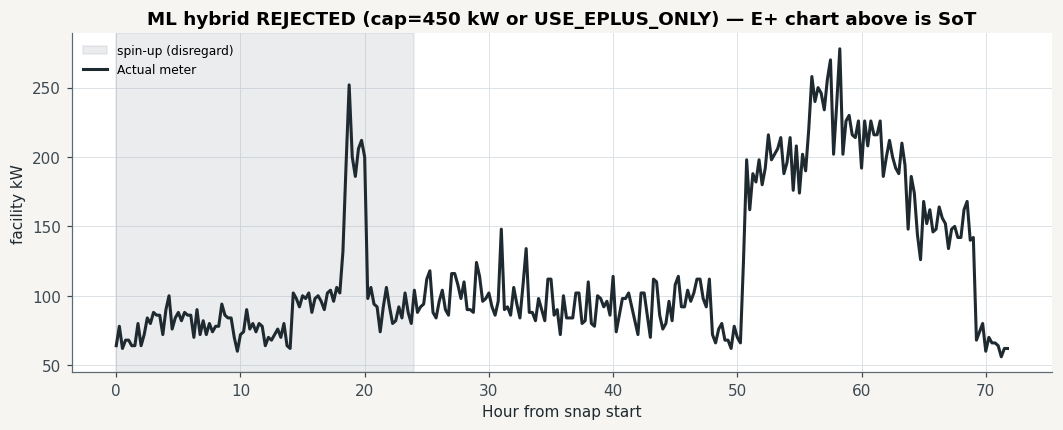

,day,weekday,spinup,peak_hybrid,peak_actual,sane,reject
0,2026-01-23,Friday,True,944.7,252.0,False,"[{'code': 'hybrid_above_plant_cap', 'detail': ..."
1,2026-01-25,Sunday,False,848.5,148.0,False,"[{'code': 'hybrid_above_plant_cap', 'detail': ..."
2,2026-01-27,Tuesday,False,664.8,278.0,False,"[{'code': 'hybrid_above_plant_cap', 'detail': ..."


ml_ok False use_eplus_only False


In [9]:
def _weather_from(df: pd.DataFrame) -> dict:
    return {
        "oat_f": [float(x) for x in df["oat_f"].to_numpy(dtype=float)[:STEPS]],
        "rh_pct": [float(x) for x in (df["rh_pct"] if "rh_pct" in df else np.full(STEPS, 55.0))],
        "ghi": [float(x) for x in (df["ghi"] if "ghi" in df else np.zeros(STEPS))],
    }

def _calendar_from(df: pd.DataFrame, day) -> dict:
    ts = pd.Timestamp(day)
    occ = (
        [float(x) for x in df["occupied"].to_numpy(dtype=float)[:STEPS]]
        if "occupied" in df.columns
        else [1.0 if 7 <= (s // 4) < 18 else 0.0 for s in range(STEPS)]
    )
    return {
        "month": float(df.iloc[0].get("month", ts.month)),
        "doy": float(df.iloc[0].get("doy", ts.dayofyear)),
        "is_weekend": float(df.iloc[0].get("is_weekend", int(ts.dayofweek >= 5))),
        "occupied_schedule": occ,
    }

def _init_from_meter(df: pd.DataFrame) -> dict:
    return {
        "facility_kw": float(df["facility_kw"].iloc[0]),
        "oat_f": float(df["oat_f"].iloc[0]),
        **{ZONE_TEMP_COLS[i]: float(df.iloc[0][ZONE_TEMP_COLS[i]]) for i in range(6)},
    }

def _init_from_walk_end(walk: dict, next_oat0: float) -> dict:
    last = walk["steps"][STEPS - 1]
    temps = last["hybrid_zone_temps_f"]
    return {
        "facility_kw": float(last["hybrid_facility_kw"]),
        "oat_f": float(next_oat0),
        **{c: float(temps[c]) for c in ZONE_TEMP_COLS},
    }

def _init_247_day0(df: pd.DataFrame) -> dict:
    oat0 = float(df["oat_f"].iloc[0])
    return {
        "facility_kw": float(_at_temp_overnight_kw(oat0)),
        "oat_f": oat0,
        **{ZONE_TEMP_COLS[i]: float(COMFORT_HTG_SP_F) for i in range(6)},
    }

def chain_snap(sched: dict, *, strategy_label: str, already_at_temp_day0: bool) -> dict:
    kw_h, kw_a = [], []
    init = None
    per_day = []
    for i, day in enumerate(snap_days):
        df = _day_frame(day)
        wx = _weather_from(df)
        cal = _calendar_from(df, day)
        if init is None:
            init = _init_247_day0(df) if already_at_temp_day0 else _init_from_meter(df)
        contract = {
            "contract_version": "hybrid_dsm_96_v1",
            "init": init,
            "weather_forecast_96": wx,
            "baseline_control_96": base_sched,
            "dsm_control_96": sched,
            "calendar": cal,
            "comfort_htg_sp_f": float(COMFORT_HTG_SP_F),
            "comfort_band_f": 2.0,
            "strategy_id": strategy_label,
        }
        walk = rollout_96(models, contract)
        h = series(walk)
        a = df["facility_kw"].to_numpy(dtype=float)[:STEPS]
        sane = bool((walk.get("summary") or {}).get("sane", True))
        kw_h.append(h); kw_a.append(a)
        per_day.append({
            "day": str(pd.Timestamp(day).date()),
            "weekday": pd.Timestamp(day).day_name(),
            "spinup": i < SPINUP_DAYS,
            "peak_hybrid": float(h.max()),
            "peak_actual": float(a.max()),
            "sane": sane,
            "reject": (walk.get("summary") or {}).get("reject_reasons"),
        })
        if i + 1 < len(snap_days):
            nxt = _day_frame(snap_days[i + 1])
            # Do not chain spiked hybrid midnight into the next day.
            if sane:
                init = _init_from_walk_end(walk, float(nxt["oat_f"].iloc[0]))
            else:
                init = _init_from_meter(nxt)
    return {
        "hybrid": np.concatenate(kw_h),
        "actual": np.concatenate(kw_a),
        "per_day": pd.DataFrame(per_day),
        "sane": bool(pd.DataFrame(per_day)["sane"].all()) if per_day else False,
    }

from hybrid_sanity import PLANT_PEAK_CAP_KW

scorecard_path = OUT / "hybrid_vs_eplus_scorecard.json"
use_eplus_only = True
if scorecard_path.is_file():
    sc = json.loads(scorecard_path.read_text(encoding="utf-8"))
    use_eplus_only = bool(sc.get("USE_EPLUS_ONLY", True))
else:
    display(Markdown("_No hybrid_vs_eplus_scorecard.json — defaulting cold-snap ML to off._"))

snap_247 = chain_snap(flat_sched, strategy_label=flat_id, already_at_temp_day0=True)
snap_nothing = chain_snap(nothing_sched, strategy_label=nothing_id, already_at_temp_day0=False)
snap_random = chain_snap(random_sched, strategy_label=random_id, already_at_temp_day0=False)

ml_ok = snap_247["sane"] and snap_nothing["sane"] and snap_random["sane"] and not use_eplus_only
t_ml = np.arange(len(snap_247["hybrid"])) / 4.0
spin_h = SPINUP_DAYS * 24.0
fig, ax = plt.subplots(figsize=(11.5, 4.0))
ax.axvspan(0, spin_h, color="#adb5bd", alpha=0.25, label="spin-up (disregard)")
ax.plot(t_ml, snap_247["actual"], color="#1f2a30", lw=2.0, label="Actual meter")
if ml_ok:
    ax.plot(t_ml, snap_247["hybrid"], color="#6c757d", lw=1.5, label=f"ML hybrid · {flat_id}")
    ax.plot(t_ml, snap_nothing["hybrid"], color="#2a9d8f", lw=1.5, label=f"ML hybrid · {nothing_id}")
    ax.plot(t_ml, snap_random["hybrid"], color="#e76f51", lw=1.6, label=f"ML hybrid · {random_id}")
    ax.set_title(f"ML hybrid on same days {snap_days}")
else:
    ax.set_title(
        f"ML hybrid REJECTED (cap={PLANT_PEAK_CAP_KW:g} kW or USE_EPLUS_ONLY) — E+ chart above is SoT"
    )
    display(Markdown(
        f"**ML cold-snap walks rejected** (plant cap {PLANT_PEAK_CAP_KW:g} kW / scorecard). "
        "Do not use these series for strategy decisions — see §7 E+-only."
    ))
ax.set_xlabel("Hour from snap start"); ax.set_ylabel("facility kW")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
save_fig(FIG / "playground_coldsnap_ml_contrast.png", fig)
plt.show(); plt.close(fig)
display(snap_247["per_day"].round(1))
print("ml_ok", ml_ok, "use_eplus_only", use_eplus_only)
